# Louvain Community Detection

This notebook applies the Louvain community detection algorithm to the weighted political collaboration network of Dutch MPs.

**Research question:** To what extent do communities in parliamentary motion collaborations correspond to formal political party affiliations?

The main analysis detects collaboration communities and compares the resulting partition with known political-party membership. A short political-compass visualization is included at the end as optional additional interpretation.


## 1. Load and inspect the collaboration network

The analysis uses the cleaned largest connected component (LCC) of the collaboration network. I used this one because the LCC removes the small disconnected components while retaining the main network structure.



In [2]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score


In [3]:
# Load the cleaned largest connected component
G = nx.read_gml(
    "../data cleaning/political_network_clean_lcc.gml"
)

# Basic network information
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Directed:", G.is_directed())
print("Weighted:", nx.is_weighted(G))


Number of nodes: 355
Number of edges: 9588
Directed: False
Weighted: True


## 2. Louvain parameter checks

In this part, I used the Louvain algorithm to detect communities in the political collaboration network. I then checked the sensitivity of the results by varying the resolution parameter and the random seed. The resolution parameter affects the number and size of the detected communities, while testing different seeds helps determine whether the community structure is reasonably stable.

In [4]:
# Compare different resolution values
resolutions = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

for r in resolutions:
    comms = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=r,
        seed=42
    )

    Q = nx.community.modularity(
        G,
        comms,
        weight="weight",
        resolution=r
    )

    print(
        f"Resolution {r}: "
        f"{len(comms)} communities, "
        f"modularity = {Q:.4f}"
    )


Resolution 0.5: 1 communities, modularity = 0.5000
Resolution 0.75: 4 communities, modularity = 0.3793
Resolution 1.0: 7 communities, modularity = 0.3224
Resolution 1.25: 9 communities, modularity = 0.2848
Resolution 1.5: 11 communities, modularity = 0.2495
Resolution 2.0: 16 communities, modularity = 0.2026


In [5]:
# Check sensitivity to the random seed at the standard resolution
seeds = [0, 1, 2, 3, 4, 42, 100, 123]

for seed in seeds:
    comms = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=1.0,
        seed=seed
    )

    Q = nx.community.modularity(
        G,
        comms,
        weight="weight",
        resolution=1.0
    )

    sizes = sorted([len(c) for c in comms], reverse=True)

    print(
        f"Seed {seed}: "
        f"{len(comms)} communities, "
        f"Q = {Q:.4f}, "
        f"sizes = {sizes}"
    )


Seed 0: 7 communities, Q = 0.3184, sizes = [82, 65, 57, 48, 45, 31, 27]
Seed 1: 7 communities, Q = 0.3195, sizes = [68, 67, 54, 49, 48, 39, 30]
Seed 2: 7 communities, Q = 0.3240, sizes = [79, 65, 60, 45, 39, 36, 31]
Seed 3: 7 communities, Q = 0.3245, sizes = [73, 70, 61, 49, 42, 30, 30]
Seed 4: 6 communities, Q = 0.3208, sizes = [87, 80, 62, 57, 48, 21]
Seed 42: 7 communities, Q = 0.3224, sizes = [79, 66, 64, 55, 37, 36, 18]
Seed 100: 7 communities, Q = 0.3231, sizes = [78, 66, 65, 48, 36, 33, 29]
Seed 123: 6 communities, Q = 0.3213, sizes = [80, 72, 63, 62, 39, 39]


A resolution of 1.0 is retained as the standard Louvain resolution. Across the tested seeds, the algorithm generally produces seven communities with similar modularity values, although the exact membership and sizes vary slightly. Seed 100 is used as a reproducible representative seven community partition for the remainder of the analysis.


## 3. Final Louvain partition

The final partition uses the collaboration frequency stored in the edge attribute `weight`, resolution 1.0, and random seed 100.


In [6]:
# Detect the final Louvain communities
communities = nx.community.louvain_communities(
    G,
    weight="weight",
    resolution=1.0,
    seed=100
)

print("Number of communities:", len(communities))

for i, community in enumerate(communities):
    print(f"Community {i}: {len(community)} MPs")


Number of communities: 7
Community 0: 33 MPs
Community 1: 48 MPs
Community 2: 29 MPs
Community 3: 65 MPs
Community 4: 36 MPs
Community 5: 66 MPs
Community 6: 78 MPs


In [7]:
# Evaluate the partition using weighted modularity
modularity = nx.community.modularity(
    G,
    communities,
    weight="weight"
)

print("Modularity:", modularity)


Modularity: 0.32314958189529125


The modularity score measures how well the network is divided into communities by comparing the observed collaborations with what would be expected under the configuration model, which is the default null model. This null model keeps the degree structure of the nodes in expectation but otherwise assumes connections are formed randomly. A higher modularity means that there is more collaboration within the detected communities than would be expected under this null model.


In [8]:
# Map every MP node to its Louvain community
community_map = {
    node: community_id
    for community_id, community in enumerate(communities)
    for node in community
}


### Network visualization

Nodes are colored according to their Louvain community. The layout is only a visualization of the network structure.


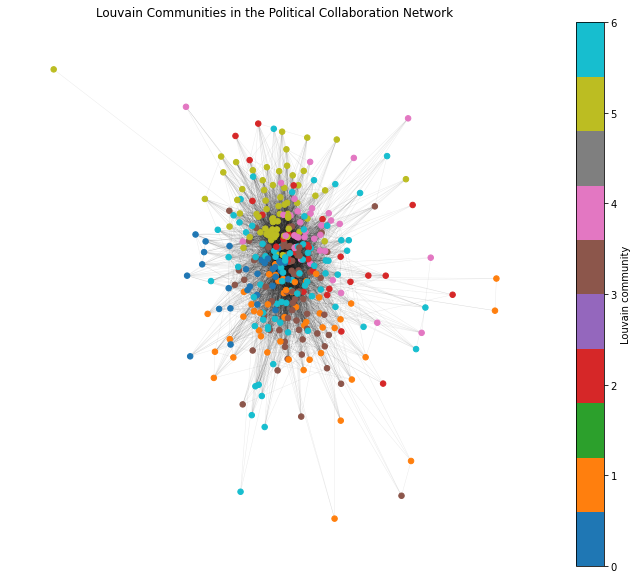

In [9]:
# Visualize the network colored by Louvain community
pos = nx.spring_layout(G, seed=42)
node_colors = [community_map[node] for node in G.nodes()]

plt.figure(figsize=(12, 10))

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.08,
    width=0.5
)

nodes_plot = nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=30
)

plt.colorbar(nodes_plot, label="Louvain community")
plt.title("Louvain Communities in the Political Collaboration Network")
plt.axis("off")
plt.show()


## 4. Party composition of the detected communities

To answer the research question, the Louvain communities are compared with the formal party affiliation stored for each MP. If collaboration communities closely followed party boundaries, individual communities would be dominated by one political party.


In [10]:
# Count political-party membership within each Louvain community
rows = []

for community_id, community in enumerate(communities):
    for node in community:
        rows.append({
            "Community": community_id,
            "Party": G.nodes[node]["party"]
        })

df = pd.DataFrame(rows)

party_community = pd.crosstab(
    df["Community"],
    df["Party"]
)

# Print detailed party counts per community
for community_id in party_community.index:
    counts = party_community.loc[community_id]
    counts = counts[counts > 0].sort_values(ascending=False)

    print(f"\nCommunity {community_id} ({counts.sum()} MPs):")
    for party, count in counts.items():
        print(f"  {party}: {count}")



Community 0 (33 MPs):
  VVD: 5
  PVV: 4
  CDA: 3
  D66: 3
  PvdA: 3
  CU: 2
  FVD: 2
  PvdD: 2
  SP: 2
  DENK: 1
  GL: 1
  Klein: 1
  Krol: 1
  SGP: 1
  Unknown: 1
  vKA: 1

Community 1 (48 MPs):
  VVD: 15
  PvdA: 12
  D66: 7
  GL: 4
  SP: 4
  CDA: 2
  CU: 1
  GrBvK: 1
  Monasch: 1
  PVV: 1

Community 2 (29 MPs):
  VVD: 8
  PvdA: 6
  SP: 4
  D66: 3
  GL: 3
  CDA: 2
  FVD: 1
  PVV: 1
  SGP: 1

Community 3 (65 MPs):
  PvdA: 13
  VVD: 11
  PVV: 8
  SP: 7
  CDA: 6
  D66: 4
  50PLUS: 3
  GL: 3
  PvdD: 3
  CU: 2
  DENK: 1
  GrBvK: 1
  Houwers: 1
  SGP: 1
  Van Vliet: 1

Community 4 (36 MPs):
  VVD: 14
  CDA: 5
  D66: 5
  PvdA: 3
  GL: 2
  PVV: 2
  SP: 2
  50PLUS: 1
  CU: 1
  Unknown: 1

Community 5 (66 MPs):
  VVD: 15
  D66: 9
  PvdA: 5
  CDA: 4
  FVD: 4
  PvdD: 3
  GL: 3
  Groep Van Haga: 3
  Unknown: 3
  JA21: 3
  Volt: 2
  CU: 2
  DENK: 2
  PVV: 2
  SGP: 1
  BBB: 1
  Omtzigt: 1
  BIJ1: 1
  Fractie Den Haan: 1
  Gündoğan: 1

Community 6 (78 MPs):
  VVD: 25
  D66: 13
  CDA: 10
  PvdA: 8
  

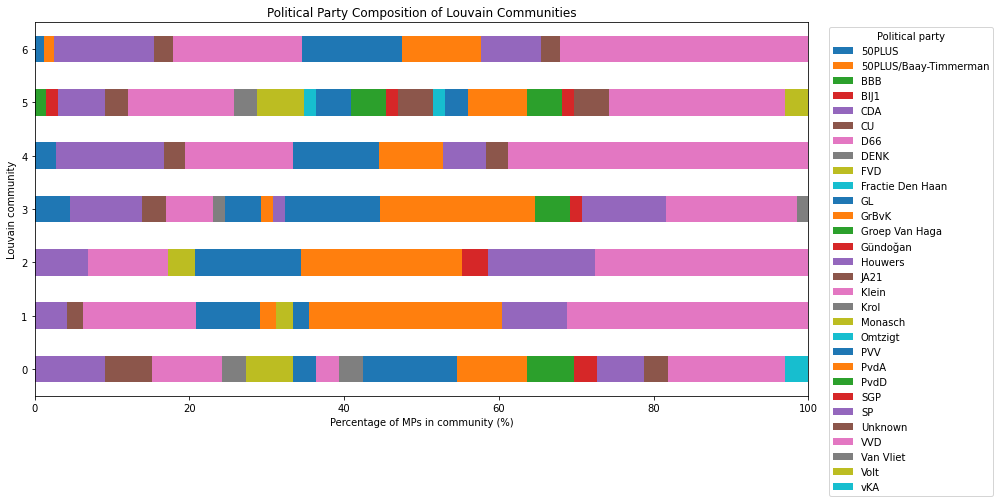

In [11]:
# Convert party counts to percentages within each community
party_percent = party_community.div(
    party_community.sum(axis=1),
    axis=0
) * 100

# 100% stacked bar chart of party composition
party_percent.plot(
    kind="barh",
    stacked=True,
    figsize=(14, 7)
)

plt.xlabel("Percentage of MPs in community (%)")
plt.ylabel("Louvain community")
plt.title("Political Party Composition of Louvain Communities")

plt.legend(
    title="Political party",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xlim(0, 100)
plt.tight_layout()
plt.show()


The stacked bars show that the Louvain communities are politically mixed rather than corresponding one-to-one with formal parties. The next measures quantify this correspondence.


## 5. Quantitative comparison with party affiliation

Three complementary measures are used:

- **NMI (Normalized Mutual Information):** measures shared information between the party partition and Louvain partition. Values range from 0 (little/no shared information) to 1 (perfect correspondence).
- **ARI (Adjusted Rand Index):** compares whether pairs of MPs are grouped together in the same way under both partitions, correcting for chance. A value near 0 indicates little agreement beyond chance.
- **Purity:** measures the share of MPs accounted for by the dominant party in each community. It is intuitive but should be interpreted together with NMI and ARI because it is affected by party-size imbalance.


In [12]:
# Create aligned party and community labels for all MPs
nodes = list(G.nodes())

party_labels = [G.nodes[node]["party"] for node in nodes]
community_labels = [community_map[node] for node in nodes]

nmi = normalized_mutual_info_score(
    party_labels,
    community_labels
)

ari = adjusted_rand_score(
    party_labels,
    community_labels
)

print("NMI between party and Louvain community:", nmi)
print("ARI between party and Louvain community:", ari)


NMI between party and Louvain community: 0.11861941679721909
ARI between party and Louvain community: 0.006567141947051267


In [13]:
# Identify the dominant political party in each community
dominant_results = []

for community_id in party_community.index:
    counts = party_community.loc[community_id]

    dominant_party = counts.idxmax()
    dominant_count = counts.max()
    total = counts.sum()
    percentage = dominant_count / total * 100

    dominant_results.append({
        "Community": community_id,
        "Size": total,
        "Dominant party": dominant_party,
        "MPs from dominant party": dominant_count,
        "Percentage": percentage
    })

dominant_df = pd.DataFrame(dominant_results)

print(dominant_df.to_string(index=False))


 Community  Size Dominant party  MPs from dominant party  Percentage
         0    33            VVD                        5   15.151515
         1    48            VVD                       15   31.250000
         2    29            VVD                        8   27.586207
         3    65           PvdA                       13   20.000000
         4    36            VVD                       14   38.888889
         5    66            VVD                       15   22.727273
         6    78            VVD                       25   32.051282


In [14]:
# Overall community purity
purity = (
    party_community.max(axis=1).sum()
    / party_community.values.sum()
)

print("Community purity:", purity)


Community purity: 0.2676056338028169


### Main interpretation

The comparison indicates limited correspondence between collaboration communities and formal party affiliation. The communities contain MPs from several political parties, and even the dominant party generally accounts for only a minority of each community.

For the selected partition, NMI is approximately 0.119, ARI approximately 0.0066, and purity approximately 0.268. Together with the party-composition visualization, these results suggest that the Louvain collaboration communities do not closely reproduce formal political-party boundaries.

This does not imply that party affiliation has no relationship with collaboration. Rather, it shows that the complete community structure detected from the weighted collaboration network cannot be explained primarily as a partition into formal parties.


## 6. Additional ideological interpretation

As an additional exploratory step, party-level political-compass coordinates from `Party.json` are connected to MPs. These coordinates describe the **party**, not the individual MP, so MPs belonging to the same party have identical `(x, y)` values.

This section is supplementary to the main research question.


In [15]:
# Load party-level political-compass information
with open("../data cleaning/raw data/Party.json", "r", encoding="utf-8") as f:
    party_data = json.load(f)

# Combine MP, party, Louvain community, and party-level coordinates
ideology_rows = []

for node in G.nodes():
    party_id = G.nodes[node].get("party_id")

    # MPs with unknown party ID cannot be assigned political coordinates
    if party_id in party_data:
        ideology_rows.append({
            "MP": G.nodes[node].get("name"),
            "Party": G.nodes[node].get("party"),
            "Community": community_map[node],
            "x": party_data[party_id]["x"],
            "y": party_data[party_id]["y"]
        })

ideology_df = pd.DataFrame(ideology_rows)

# Ensure coordinates are numeric
ideology_df["x"] = pd.to_numeric(ideology_df["x"])
ideology_df["y"] = pd.to_numeric(ideology_df["y"])

print("MPs with political-compass coordinates:", len(ideology_df))
print("MPs without political-compass coordinates:", G.number_of_nodes() - len(ideology_df))


MPs with political-compass coordinates: 348
MPs without political-compass coordinates: 7


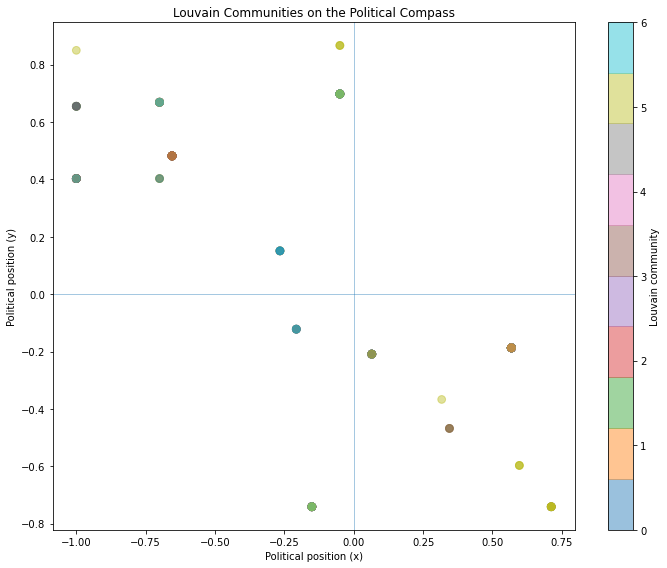

In [16]:
# Exploratory political-compass visualization
# Points may overlap because all MPs from the same party share the same coordinates.
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    ideology_df["x"],
    ideology_df["y"],
    c=ideology_df["Community"],
    cmap="tab10",
    alpha=0.45,
    s=60
)

plt.axhline(0, linewidth=0.8, alpha=0.5)
plt.axvline(0, linewidth=0.8, alpha=0.5)

plt.xlabel("Political position (x)")
plt.ylabel("Political position (y)")
plt.title("Louvain Communities on the Political Compass")

cbar = plt.colorbar(scatter)
cbar.set_label("Louvain community")

plt.tight_layout()
plt.show()


## 7. Summary

Using weighted Louvain community detection on the cleaned largest connected component:

- the selected partition contains **7 collaboration communities**;
- its modularity is approximately **0.323**;
- communities contain substantial mixtures of political parties;
- dominant-party shares are relatively low across communities;
- **NMI ≈ 0.119**, **ARI ≈ 0.0066**, and **purity ≈ 0.268** all indicate limited correspondence between the Louvain partition and formal party affiliation.

Overall, the detected collaboration communities do not closely reproduce formal political-party groupings. The political-compass analysis is retained only as optional exploratory interpretation.


In [17]:
# Save the final Louvain community assignment for each MP
louvain_mapping = pd.DataFrame([
    {
        "MP_ID": node,
        "MP": G.nodes[node].get("name"),
        "Party": G.nodes[node].get("party"),
        "Louvain_Community": community_map[node]
    }
    for node in G.nodes()
])

louvain_mapping.to_csv(
    "louvain_community_mapping.csv",
    index=False
)

louvain_mapping.head()

,MP_ID,MP,Party,Louvain_Community
0,cf4c4d24-798d-4bbe-bf06-23ca674f0d28,P.E. (Pieter) Heerma,CDA,0
1,cefbf19c-653b-4af7-84a6-e17fba0e4a70,A. van Ojik,GL,1
2,16be6093-7884-4d00-ae31-70dc7062f57a,E.M.J. Ploumen,PvdA,1
3,44081df1-828e-4d79-bd27-261be38f66f1,H. Nijboer,PvdA,3
4,66b2be3d-10f8-46a4-90c6-b86005df0a50,S. Maatoug,GL,5
